# Synthetic biomarker benchmark — PVBM

The generated pages hold the facts: [how it is run](../docs/benchmarks/biomarker-synthetic-docs.md)
and [what came out](../docs/benchmarks/biomarker-synthetic-pvbm-results.md). The shapes and the
values their geometry requires are in [the shapes notebook](biomarker-synthetic-shapes.ipynb). This
notebook is where the judgement goes, for **one implementation**: a second gets a notebook of its
own rather than a column here.

**The question is not whether two implementations agree.** It is whether one of them computes the
quantity it is said to compute, measured against a number derived on paper. A straight vessel has a
tortuosity of exactly 1; an implementation that says otherwise is wrong, and the interesting part
is *by how much and in what pattern*, because the pattern says what it is doing instead.

Every shape was drawn at four angles. The geometry is identical at each, so anything that moves is
the grid or the implementation, never the retina.

| | |
| --- | --- |
| **1** | what was measured, and what could be compared |
| **2** | what PVBM gets right |
| **3** | **every issue in one place** — what raised, what turns with the image, what is far from the geometry |
| **4–7** | why each of those happens, from reading the source |
| **9** | OCULAR: the same code, modified |
| **10** | what this analysis cannot say |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def repository() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"nothing above {Path.cwd()} looks like the fundus-atlas repository")


ROOT = repository()
sys.path.insert(0, str(ROOT / "src"))
RESULTS = ROOT / "results" / "biomarker-synthetic"

from benchmarks import biomarker_synthetic as benchmark  # noqa: E402
from benchmarks.shapes import library  # noqa: E402
from biomarkers.utils import catalogue  # noqa: E402

#: Each adapter carries its own table from the implementation's metric names onto catalogued ones,
#: and answers under the catalogued name, so the evidence needs no translation here. This is only
#: to show what was mapped onto what.
NAMES = catalogue.load("pvbm").declare()["names"]


#: This notebook is about one implementation. `results/` now holds several, and a column one of
#: them does not compute is not a missing value — it is a different program. Sections 1 to 8 read
#: PVBM alone; section 9 reads OCULAR beside it deliberately.
SUBJECT = "pvbm"


def evidence() -> pd.DataFrame:
    """Every rendering of this notebook's subject, one row each, as the run recorded it."""
    frames = []
    for path in sorted((RESULTS / SUBJECT).glob("*.csv")):
        frame = pd.read_csv(path)
        frame["implementation"] = path.parent.name
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"no results in {RESULTS} — run the benchmark first")
    return pd.concat(frames, ignore_index=True)


def comparisons(rows: pd.DataFrame) -> pd.DataFrame:
    """One row per (rendering, quantity) where the shape defines a value to compare against.

    The evidence keeps what was said and what geometry requires side by side; putting them in one
    frame with the difference is the first thing an analysis does and the last thing the evidence
    should.
    """
    found = []
    for _, row in rows.iterrows():
        for name in rows.columns:
            if not name.startswith("said_"):
                continue
            key = name[len("said_") :]
            said, theory = row[name], row.get(f"theory_{key}")
            if pd.isna(said) or pd.isna(theory):
                continue
            found.append(
                {
                    "implementation": row["implementation"],
                    "shape": row["shape"],
                    "rotation": row["rotation"],
                    "metrics": key,
                    "canonical": row.get(f"canonical_{key}", ""),
                    "said": float(said),
                    "theory": float(theory),
                    "relative error": (float(said) - float(theory)) / float(theory)
                    if float(theory)
                    else np.nan,
                }
            )
    return pd.DataFrame(found)


rows = evidence()
compared = comparisons(rows)
print(f"{len(rows)} renderings · {compared['implementation'].nunique()} implementation(s) · "
      f"{compared['shape'].nunique()} shapes · {len(compared)} comparable measurements")
print("angles:", sorted(rows["rotation"].unique()))

32 renderings · 1 implementation(s) · 8 shapes · 262 comparable measurements
angles: [np.float64(0.0), np.float64(30.0), np.float64(60.0), np.float64(90.0)]


## 1. What was measured, and what could be compared

Three different things stand between a metric PVBM computes and a number this benchmark can judge,
and keeping them apart is the first thing an analysis owes a reader:

- **The catalogue may have no name for it.** PVBM's perimeter, its singularity length and the three
  statistics of its branching angle describe quantities nothing else here computes. Those metrics
  are measured and stored under PVBM's own names — a name exists to make two numbers comparable,
  and there is no second number yet.
- **No shape may define it.** A fractal dimension has a catalogued name and no shape here pins a
  value for it, so it is reported and not checked.
- **PVBM may not report it per class.** Several shapes state a value over the vessels as one class,
  `junction-counts/junctions/vessels` among them, and PVBM measures each class separately. Those
  values go unused rather than being compared against half the picture.

A metric carrying a `/` is answered under a catalogued name; one without it is PVBM's own.

In [2]:
said_metrics = sorted({c[len("said_"):] for c in rows.columns if c.startswith("said_")})
reported = [c for c in said_metrics if rows[f"said_{c}"].notna().any()]
# A name carrying a `/` is a catalogued biomarker; one without it is PVBM's own, kept because the
# catalogue has no name for that quantity yet.
catalogued = [c for c in said_metrics if "/" in c]
checkable = sorted(compared["metrics"].unique())

pd.DataFrame(
    {
        "metrics PVBM computes": [len(said_metrics)],
        "metrics it returned a value for": [len(reported)],
        "metrics with a catalogued name": [len(catalogued)],
        "metrics kept under PVBM's own name": [len(said_metrics) - len(catalogued)],
        "metrics a shape gives a value to check": [len(checkable)],
    }
).T.rename(columns={0: "count"})

,count
metrics PVBM computes,32
metrics it returned a value for,32
metrics with a catalogued name,22
metrics kept under PVBM's own name,10
metrics a shape gives a value to check,16


### 1.1 Catalog biometrics that have no true (ground truth) value to compare

In [3]:
# What is reported but never checked, and why — the two reasons are different.
unchecked = []
for metric in reported:
    if metric in checkable:
        continue
    named = "/" in metric
    if named:
        unchecked.append(
            {
                "metrics": metric,
                "PVBM calls it": NAMES[metric],
                "why unchecked": "no shape defines it",
            }
        )
pd.DataFrame(unchecked).set_index("metrics")

,PVBM calls it,why unchecked
metrics,,
fractal-dimension/multifractal-d0/artery,capacity_dimension_artery,no shape defines it
fractal-dimension/multifractal-d0/vein,capacity_dimension_vein,no shape defines it
fractal-dimension/multifractal-d1/artery,entropy_dimension_artery,no shape defines it
fractal-dimension/multifractal-d1/vein,entropy_dimension_vein,no shape defines it
fractal-dimension/multifractal-d2/artery,correlation_dimension_artery,no shape defines it
fractal-dimension/multifractal-d2/vein,correlation_dimension_vein,no shape defines it


### 1.2 PVBM metrics that have no matching catalog canonical names

In [4]:
unchecked = []
for metric in reported:
    if metric in checkable:
        continue
    named = "/" in metric
    if named:
        continue
    unchecked.append(
        {
            "metrics": metric,
            "why unchecked": "PVBM's own name is not a catalogued biomarker",

        }
    )
pd.DataFrame(unchecked).set_index("metrics")

,why unchecked
metrics,
mean_branching_angle_artery,PVBM's own name is not a catalogued biomarker
mean_branching_angle_vein,PVBM's own name is not a catalogued biomarker
median_branching_angle_artery,PVBM's own name is not a catalogued biomarker
median_branching_angle_vein,PVBM's own name is not a catalogued biomarker
perimeter_artery,PVBM's own name is not a catalogued biomarker
perimeter_vein,PVBM's own name is not a catalogued biomarker
singularity_length_artery,PVBM's own name is not a catalogued biomarker
singularity_length_vein,PVBM's own name is not a catalogued biomarker
std_branching_angle_artery,PVBM's own name is not a catalogued biomarker


## 2. What PVBM gets exactly right

Two quantities land on the geometry at every shape and every angle. They are worth stating first,
because the rest of this notebook is about the ones that do not, and a reader should not come away
thinking the implementation is poor.

**Area** is measured across four shapes and two classes, 56 comparisons, never worse than 0.3% and
usually inside 0.05%. **Endpoint counts** are exact — 24 comparisons, not one of them off by one.
Both are what a careful implementation of an easy definition looks like.

In [5]:
WORST_ERROR_THRESHOLD = 0.10
# For each metric, aggregate over all shapes/rotations: show metrics whose worst absolute error is below the threshold,
# present: the number of samples (with both 'said' and 'theory' filled), the worst error, and the median error (all abs).
summary = (
    compared.dropna(subset=["said", "theory"])
    .groupby("metrics")["relative error"]
    .agg(
        samples="count",
        worst=lambda e: e.abs().max(),
        median=lambda e: e.abs().median()
    )
)
good_metrics = summary[summary["worst"] < WORST_ERROR_THRESHOLD]
EXACT = tuple(good_metrics.index)

styled = good_metrics.assign(samples=good_metrics["samples"].astype(int)).style.format(
    {"worst": "{:.2%}", "median": "{:.2%}", "samples": "{:d}"}
)
styled = styled.set_properties(subset=["samples"], **{'text-align': 'right'}).set_properties(subset=["worst", "median"], **{'text-align': 'right'})
styled.set_table_styles(
    [
        {"selector": "th.row_heading", "props": [("text-align", "left")]},
        {"selector": "th.index_name", "props": [("text-align", "left")]},
    ]
)

,samples,worst,median
metrics,,,
avr/knudtson/both,10,3.80%,3.79%
central-retinal-equivalents/knudtson/artery,10,6.33%,6.33%
central-retinal-equivalents/knudtson/vein,10,2.64%,2.64%
junction-counts/endpoints/artery,12,0.00%,0.00%
junction-counts/endpoints/vein,12,0.00%,0.00%
tortuosity/hart-tau1/artery,28,7.40%,6.70%
tortuosity/hart-tau1/vein,28,7.32%,6.63%
vessel-area-and-length/area/artery,28,0.29%,0.02%
vessel-area-and-length/area/vein,28,0.09%,0.01%


## 3. Every issue, in one place

Section 2 listed what PVBM gets right. This section is the complement: **everything that went
wrong, of every kind**, before any of it is explained. The explanations are sections 4 to 7, and a
reader who wants only the list can stop at the end of this one.

Three kinds of thing can go wrong, and they are different in nature rather than in degree:

| | What it means |
| --- | --- |
| **3.1** | the implementation **raised** instead of returning a number |
| **3.2** | it returned a number that **moves when the shape is turned**, where the geometry does not |
| **3.3** | it returned a stable number that is **far from what the geometry requires** |

### 3.1 Renderings that raised instead of measuring

A measurement that fell over is recorded in the evidence's `note`, beside the quantities that were
measured on the same rendering — so one failing call loses its own answer and nothing else.

The table below is every rendering that raised, with the skeleton length of each class read from
the stored masks, because that is the quantity the failure depends on.

In [6]:
from benchmarks.shapes import store  # noqa: E402
from skimage.morphology import skeletonize  # noqa: E402

STORE = ROOT / store.STORE
RECURSION_LIMIT = sys.getrecursionlimit()


def skeleton_pixels(shape: str, rotation: float) -> dict[str, int]:
    """How many pixels each class skeletonises to, from the stored masks the run measured."""
    rendering = store.load(STORE, store.key_of(shape, benchmark.SIDE, rotation))
    return {
        "artery skeleton, px": int(skeletonize(rendering.artery).sum()),
        "vein skeleton, px": int(skeletonize(rendering.vein).sum()),
    }


trouble = []
for _, row in rows.iterrows():
    if pd.isna(row["note"]) or not str(row["note"]).strip():
        continue
    raised = sorted({part.split(":")[0].strip() for part in str(row["note"]).split(";")})
    trouble.append(
        {
            "shape": row["shape"],
            "rotation": row["rotation"],
            "what raised": ", ".join(raised),
            "exception": "RecursionError" if "RecursionError" in row["note"] else row["note"][:40],
            **skeleton_pixels(row["shape"], row["rotation"]),
        }
    )
trouble = pd.DataFrame(trouble)
print(f"{len(trouble)} of {len(rows)} renderings raised · Python's recursion limit is {RECURSION_LIMIT}")
trouble.set_index(["shape", "rotation"])

10 of 32 renderings raised · Python's recursion limit is 1000


what raised  \
shape            rotation                                         
artery-vein-pair 0.0       equivalents_artery, equivalents_vein   
                 90.0      equivalents_artery, equivalents_vein   
sinusoid         0.0                         equivalents_artery   
                 30.0      equivalents_artery, equivalents_vein   
                 60.0      equivalents_artery, equivalents_vein   
                 90.0      equivalents_artery, equivalents_vein   
straight         0.0       equivalents_artery, equivalents_vein   
                 30.0      equivalents_artery, equivalents_vein   
                 60.0      equivalents_artery, equivalents_vein   
                 90.0      equivalents_artery, equivalents_vein   

                                exception  artery skeleton, px  \
shape            rotation                                        
artery-vein-pair 0.0       RecursionError                 1020   
                 90.0      RecursionError                 1019   
sinusoid         0.0       RecursionError                 1025   
                 30.0      RecursionError                 1161   
                 60.0      RecursionError                 1159   
                 90.0      RecursionError                 1025   
straight         0.0       RecursionError                 1227   
                 30.0      RecursionError                 1067   
                 60.0      RecursionError                 1067   
                 90.0      RecursionError                 1225   

                           vein skeleton, px  
shape            rotation                     
artery-vein-pair 0.0                    1022  
                 90.0                   1023  
sinusoid         0.0                    1010  
                 30.0                   1160  
                 60.0                   1159  
                 90.0                   1025  
straight         0.0                    1231  
                 30.0                   1065  
                 60.0                   1064  
                 90.0                   1229

**Every failure in this run is the same failure**, and it has one cause.

`compute_central_retinal_equivalents` walks each vessel with `tree.recursive_reg`, which calls
itself **once per skeleton pixel**. Python's default limit is 1000 stack frames, so a vessel long
enough to exhaust it cannot be walked and the call raises.

**The boundary is near 1000 but not exactly at it**, and the table shows where: a vein of 1010
skeleton pixels was measured without complaint, and an artery of 1019 raised. The walk does not
begin on an empty stack and does not descend once per pixel in a simple chain, so the usable
length is a little under the limit rather than equal to it. Every class that raised here is above
1019 pixels; everything measured is at or below 1010.

Three things follow.

- **It is a property of the image, not of the retina.** The same vessel on a 512-pixel frame
  skeletonises to about 400 pixels and is measured without complaint. Anyone running PVBM on a
  modern 2048-pixel photograph is nearer this cliff than anyone running it on the small images its
  examples use.
- **Whether it happens depends on the orientation.** On the artery/vein pair the artery skeleton is
  1020 pixels at 0° and 888 at 30°, because a tilted digital line spends fewer pixels covering the
  same distance — a diagonal step advances √2. The pair raises at 0° and 90° and is measured at 30°
  and 60°: **the same vessel in the same eye is measurable or not according to how the camera was
  held.**
- **It fails loudly.** It raises rather than returning a wrong number, which is much the better of
  the two failure modes, and is why this is a limit to know about rather than a silent corruption.

It cost the equivalents on 10 of the 32 renderings, and nothing else in this run raised at all.

### 3.2 Measurements that move when the shape is turned

A rotation changes nothing a measurement should see: the shape is turned in continuous coordinates
and drawn again, so the vessel is identical and only the pixels it lands on differ. **Any spread
across the four angles is the implementation or the grid, never the retina.**

This is measured over **every** quantity PVBM returns, catalogued or not — a proprietary column
that turns with the image is as unusable as a catalogued one that does.

In [7]:
turned = rows.melt(
    id_vars=["shape", "rotation"],
    value_vars=[f"said_{m}" for m in reported],
    var_name="metrics",
    value_name="said",
).dropna(subset=["said"])
turned["metrics"] = turned["metrics"].str[len("said_") :]

spread = turned.groupby(["shape", "metrics"])["said"].agg(
    angles="count", lowest="min", highest="max", typical="mean"
)
spread = spread[spread["angles"] > 1]
spread["spread"] = spread["highest"] - spread["lowest"]
# Relative to the typical value, except where that is zero — a junction count of zero at every
# angle is perfect agreement, not an infinite error.
spread["turns by"] = np.where(
    spread["typical"].abs() > 0, spread["spread"] / spread["typical"].abs(), 0.0
)
spread["named"] = ["catalogued" if "/" in m else "PVBM's own" for _, m in spread.index]

moving = spread[spread["turns by"] > 0.001].sort_values("turns by", ascending=False)
print(f"{len(moving)} of {len(spread)} (shape, metric) pairs move with the angle")
moving.round(4)

114 of 198 (shape, metric) pairs move with the angle


angles      lowest  \
shape       metrics                                                             
bifurcation std_branching_angle_vein                            4      0.0000   
            std_branching_angle_artery                          4      0.0000   
            junction-counts/junctions/vein                      4      1.0000   
            junction-counts/junctions/artery                    4      1.0000   
            mean_branching_angle_artery                         4     79.7138   
...                                                           ...         ...   
            tortuosity/hart-tau1/artery                         4      1.0736   
arc         vessel-area-and-length/area/artery                  4  15636.0000   
disjoint    vessel-area-and-length/skeleton-length/artery       4   3274.0012   
sinusoid    vessel-area-and-length/area/vein                    4  30380.0000   
bifurcation vessel-area-and-length/skeleton-length/vein         4   1095.8365   

                                                              highest  \
shape       metrics                                                     
bifurcation std_branching_angle_vein                           5.3127   
            std_branching_angle_artery                         2.3421   
            junction-counts/junctions/vein                     4.0000   
            junction-counts/junctions/artery                   4.0000   
            mean_branching_angle_artery                      133.9757   
...                                                               ...   
            tortuosity/hart-tau1/artery                        1.0752   
arc         vessel-area-and-length/area/artery             15658.0000   
disjoint    vessel-area-and-length/skeleton-length/artery   3278.5135   
sinusoid    vessel-area-and-length/area/vein               30414.0000   
bifurcation vessel-area-and-length/skeleton-length/vein     1097.0418   

                                                              typical  \
shape       metrics                                                     
bifurcation std_branching_angle_vein                           1.3413   
            std_branching_angle_artery                         0.6331   
            junction-counts/junctions/vein                     3.0000   
            junction-counts/junctions/artery                   3.0000   
            mean_branching_angle_artery                      106.8525   
...                                                               ...   
            tortuosity/hart-tau1/artery                        1.0744   
arc         vessel-area-and-length/area/artery             15647.0000   
disjoint    vessel-area-and-length/skeleton-length/artery   3276.0751   
sinusoid    vessel-area-and-length/area/vein               30400.5000   
bifurcation vessel-area-and-length/skeleton-length/vein     1096.3692   

                                                            spread  turns by  \
shape       metrics                                                            
bifurcation std_branching_angle_vein                        5.3127    3.9609   
            std_branching_angle_artery                      2.3421    3.6993   
            junction-counts/junctions/vein                  3.0000    1.0000   
            junction-counts/junctions/artery                3.0000    1.0000   
            mean_branching_angle_artery                    54.2618    0.5078   
...                                                            ...       ...   
            tortuosity/hart-tau1/artery                     0.0016    0.0015   
arc         vessel-area-and-length/area/artery             22.0000    0.0014   
disjoint    vessel-area-and-length/skeleton-length/artery   4.5123    0.0014   
sinusoid    vessel-area-and-length/area/vein               34.0000    0.0011   
bifurcation vessel-area-and-length/skeleton-length/vein     1.2053    0.0011   

                                                                

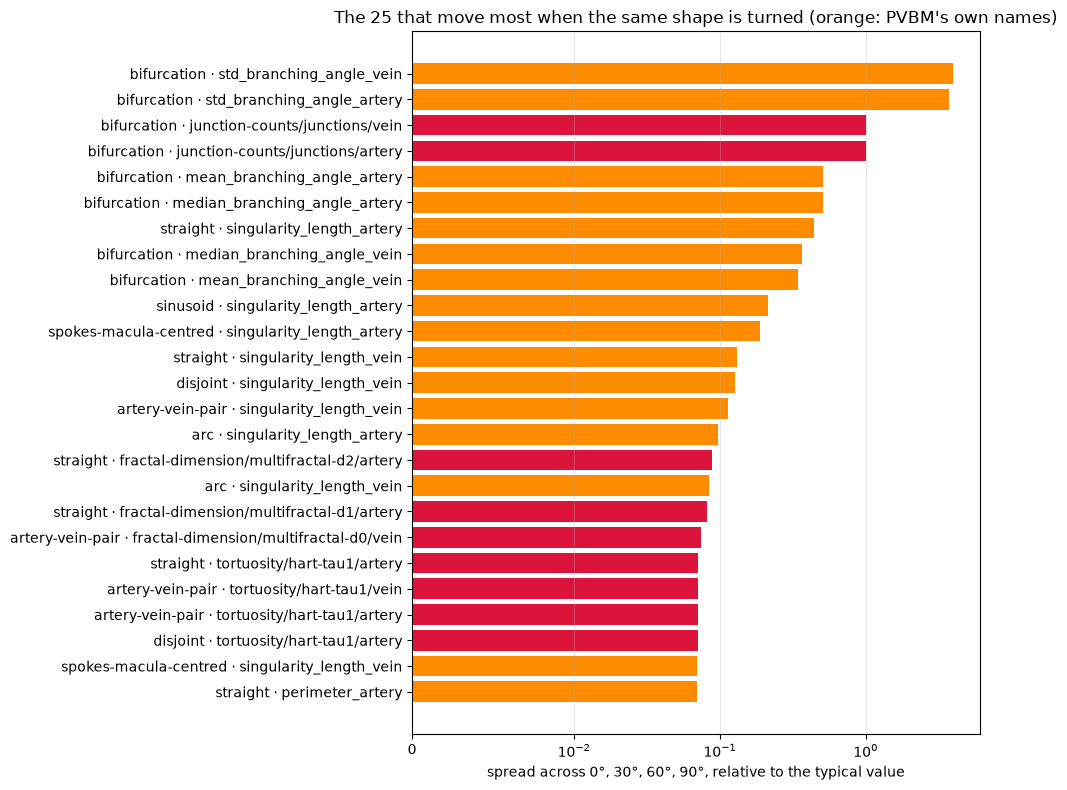

In [8]:
SHOWN = 25
top = moving.head(SHOWN)
fig, axis = plt.subplots(figsize=(10, max(3.0, 0.32 * len(top))))
labels = [f"{shape} · {metric}" for shape, metric in top.index][::-1]
colours = ["crimson" if kind == "catalogued" else "darkorange" for kind in top["named"]][::-1]
axis.barh(labels, top["turns by"].to_numpy()[::-1], color=colours)
axis.set_xscale("symlog", linthresh=0.01)
axis.set_xlabel("spread across 0°, 30°, 60°, 90°, relative to the typical value")
axis.set_title(f"The {SHOWN} that move most when the same shape is turned "
               f"(orange: PVBM's own names)")
axis.grid(axis="x", alpha=0.3)
fig.tight_layout()

**114 of the 198 (shape, quantity) pairs move at all.** Most move slightly, which is the raster;
these move enough to matter, in descending order:

| What moves | Range across the four angles | |
| --- | --- | --- |
| `std_branching_angle` on the bifurcation | **0 → 5.31°** | PVBM's own |
| `junction-counts/junctions` on the bifurcation | **1 → 4** | catalogued |
| `mean`/`median_branching_angle` on the bifurcation | **79.7° → 134.0°** | PVBM's own |
| `singularity_length`, on every shape | up to **44%** of its own value | PVBM's own |
| `tortuosity/hart-tau1`, on every shape with one | about **7%** | catalogued |

Two things stand out.

**The least stable quantities are the ones the catalogue cannot name.** The three branching-angle
statistics and the singularity length are PVBM's own columns, so nothing checks them against a
theoretical value — and they are the ones that move most. A spread of 0° to 5.31° on a shape whose
junction is perfectly symmetric at every angle says the collection of angles being averaged is
itself changing with the lattice. Being unnameable and being unstable are not the same defect, and
here they coincide.

**Everything that moves traces back to two causes**, both in sections 4 and 5: a junction that is a
cluster of pixels rather than a point, which changes size as the branches fall differently on the
grid and takes every angle statistic with it; and a walk that counts steps rather than measuring
length, which is the tortuosity.

**What does not move is worth as much.** Area, endpoint counts and both central retinal equivalents
are steady across all four angles — including the equivalents, which are anchored on the disc and
could easily have read the framing instead of the eye.

### 3.3 Measurements far from what the geometry requires

Section 2 kept the quantities whose worst error is under 10%. These are the rest: stable answers,
repeatable answers, and a long way from the value the shape defines.

Grouped by biomarker family, because the pattern is a family's rather than a column's — and with
the shape where each is worst, since that is usually what identifies the cause.

In [9]:
poor = summary[summary["worst"] >= WORST_ERROR_THRESHOLD].copy()
worst_on = (
    compared.assign(size=compared["relative error"].abs())
    .sort_values("size")
    .groupby("metrics")
    .tail(1)
    .set_index("metrics")
)
poor["family"] = [m.split("/")[0] if "/" in m else "PVBM's own" for m in poor.index]
poor["worst on"] = worst_on.loc[poor.index, "shape"]
poor["direction"] = np.where(worst_on.loc[poor.index, "relative error"] < 0, "under", "over")
poor = poor.reset_index().set_index(["family", "metrics"]).sort_index()
poor[["samples", "worst", "median", "worst on", "direction"]].round(4)

samples  \
family                      metrics                                                  
avr                         avr/hubbard/both                                     8   
central-retinal-equivalents central-retinal-equivalents/hubbard/artery           8   
                            central-retinal-equivalents/hubbard/vein             8   
junction-counts             junction-counts/junctions/artery                     4   
                            junction-counts/junctions/vein                       4   
vessel-area-and-length      vessel-area-and-length/skeleton-length/artery       32   
                            vessel-area-and-length/skeleton-length/vein         32   

                                                                            worst  \
family                      metrics                                                 
avr                         avr/hubbard/both                               0.3216   
central-retinal-equivalents central-retinal-equivalents/hubbard/artery     0.8136   
                            central-retinal-equivalents/hubbard/vein       0.7253   
junction-counts             junction-counts/junctions/artery               3.0000   
                            junction-counts/junctions/vein                 3.0000   
vessel-area-and-length      vessel-area-and-length/skeleton-length/artery  0.1812   
                            vessel-area-and-length/skeleton-length/vein    0.1909   

                                                                           median  \
family                      metrics                                                 
avr                         avr/hubbard/both                               0.3216   
central-retinal-equivalents central-retinal-equivalents/hubbard/artery     0.8136   
                            central-retinal-equivalents/hubbard/vein       0.7252   
junction-counts             junction-counts/junctions/artery               2.5000   
                            junction-counts/junctions/vein                 2.5000   
vessel-area-and-length      vessel-area-and-length/skeleton-length/artery  0.0034   
                            vessel-area-and-length/skeleton-length/vein    0.0061   

                                                                                        worst on  \
family                      metrics                                                                
avr                         avr/hubbard/both                                 spokes-disc-centred   
central-retinal-equivalents central-retinal-equivalents/hubbard/artery     spokes-macula-centred   
                            central-retinal-equivalents/hubbard/vein       spokes-macula-centred   
junction-counts             junction-counts/junctions/artery                         bifurcation   
                            junction-counts/junctions/vein                           bifurcation   
vessel-area-and-length      vessel-area-and-length/skeleton-length/artery               sinusoid   
                            vessel-area-and-length/skeleton-length/vein                 sinusoid   

                                                                          direction  
family                      metrics                                                  
avr                         avr/hubbard/both                                  under  
central-retinal-equivalents central-retinal-equivalents/hubbard/artery        under  
                            central-retinal-equivalents/hubbard/vein          under  
junction-counts             junction-counts/junctions/artery                   over  
                            junction-counts/junctions/vein                     over  
vessel-area-and-length      vessel-area-and-length/skeleton-length/artery     under  
                            vessel-area-and-length/skeleton-length/vein       under

**Four families in the table, and three kinds of wrong** — `avr/hubbard` being its own family and
inheriting its error wholesale from the equivalents it divides.

- **`vessel-area-and-length/skeleton-length`** is short on every shape and worst on the curviest:
  18% on the sinusoid, 10% on the arc, a fraction of a per cent on a straight vessel. That is the
  signature of a chord rather than an arc — section 4.
- **`central-retinal-equivalents/hubbard`** is 73–81% low, and `avr/hubbard` 32% low with it. Not a
  unit away from right: the arteries and the veins are out by *different* factors, which is what
  makes it a dimensional error rather than a conversion — section 7.
- **`junction-counts/junctions`** is up to 300% over, on the bifurcation — the same defect as its
  rotation sensitivity in 3.2, seen from the other side, and the only family here that reads high.

Note what is **not** in this table: the branching angle, which used to head it. It maps to no
catalogued biomarker, so nothing is compared against it and no error is charged — section 6.

## 4. Every metric at a glance

One row per quantity PVBM computes — all of them, catalogued or not — and the three questions of
section 3 asked of each. This is the table to read if you read nothing else, and the one to check
before relying on any single number PVBM reports.

| Mark | Means |
| --- | --- |
| **raised** | the call threw an exception on at least one rendering, so there is no number at all |
| **turns** | the answer moves across 0°, 30°, 60° and 90°, where the geometry is identical |
| **differs** | the answer is stable and more than 10% from what the shape's geometry requires |
| `—` | the question does not arise: nothing raised, nothing moved, or nothing defines a value |
| **declined** | PVBM looked and returned nothing, raising nothing — a different thing from failing |
| `not checked` | no shape pins a value for it, so the last column cannot be asked at all |

A blank in the last column is **not** a pass. Ten of the thirty-two quantities have no catalogued
name, and six more have a name no shape gives a value to; none of those is verified by anything
here, and that is a gap in this benchmark rather than a property of the implementation.

In [10]:
TURNS_THRESHOLD = 0.01

#: Which of PVBM's calls each quantity comes out of. A failure is recorded per call, so this is
#: what attributes a missing value to the failure that caused it rather than to every quantity of
#: the same rendering — a branching angle is empty on a shape with no junctions whether or not the
#: equivalents raised beside it.
CALLS = catalogue.load("pvbm").declare()["calls"]
notes = rows["note"].fillna("").astype(str)
by_metric = spread.groupby("metrics")["turns by"].max()

glance = []
for metric in said_metrics:
    missing = rows[f"said_{metric}"].isna()
    blamed = notes.apply(lambda note: any(call in note for call in CALLS[metric]))
    raised = int((missing & blamed).sum())
    # Missing with nothing raised against it is a decline, not a failure: PVBM looked and had no
    # answer, which several shapes legitimately provoke.
    declined = int((missing & ~blamed).sum())
    turns = float(by_metric.get(metric, np.nan))
    checked = metric in summary.index
    differs = float(summary.loc[metric, "worst"]) if checked else np.nan

    glance.append(
        {
            "metric": metric,
            "kind": "catalogued" if "/" in metric else "PVBM's own",
            "raised": f"⚠ {raised} of {len(rows)}" if raised else "—",
            "declined": str(declined) if declined else "—",
            "turns": (("⚠ " if turns > TURNS_THRESHOLD else "") + f"{turns:.1%}")
            if np.isfinite(turns)
            else "—",
            "differs": (
                ("⚠ " if differs >= WORST_ERROR_THRESHOLD else "") + f"{differs:.1%}"
                if checked
                else "not checked"
            ),
            "_rank": (raised > 0) * 4
            + (turns > TURNS_THRESHOLD) * 2
            + int(checked and differs >= WORST_ERROR_THRESHOLD),
        }
    )

glance = (
    pd.DataFrame(glance)
    .sort_values(["_rank", "kind", "metric"], ascending=[False, True, True])
    .drop(columns="_rank")
    .set_index("metric")
)
print(
    f"{len(glance)} quantities · {(glance['raised'] != '—').sum()} lost to an exception · "
    f"{glance['turns'].str.startswith('⚠').sum()} turn with the image · "
    f"{glance['differs'].str.startswith('⚠').sum()} differ from geometry · "
    f"{(glance['differs'] == 'not checked').sum()} never checked"
)
glance.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [
        {"selector": "th.row_heading", "props": [("text-align", "left")]},
        {"selector": "th.index_name", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("text-align", "left")]},
    ]
)

32 quantities · 6 lost to an exception · 27 turn with the image · 7 differ from geometry · 16 never checked


,kind,raised,declined,turns,differs
metric,,,,,
avr/hubbard/both,catalogued,⚠ 10 of 32,4,⚠ 4.9%,⚠ 32.2%
central-retinal-equivalents/hubbard/artery,catalogued,⚠ 10 of 32,4,⚠ 2.9%,⚠ 81.4%
central-retinal-equivalents/hubbard/vein,catalogued,⚠ 9 of 32,—,⚠ 4.2%,⚠ 72.5%
avr/knudtson/both,catalogued,⚠ 10 of 32,4,⚠ 5.8%,3.8%
central-retinal-equivalents/knudtson/artery,catalogued,⚠ 10 of 32,4,⚠ 2.9%,6.3%
central-retinal-equivalents/knudtson/vein,catalogued,⚠ 9 of 32,—,⚠ 4.2%,2.6%
junction-counts/junctions/artery,catalogued,—,—,⚠ 100.0%,⚠ 300.0%
junction-counts/junctions/vein,catalogued,—,—,⚠ 100.0%,⚠ 300.0%
vessel-area-and-length/skeleton-length/vein,catalogued,—,—,⚠ 1.6%,⚠ 19.1%


**Read the table by its rows, not its columns.** A quantity with no mark is one this benchmark
could check and found sound, on these shapes, at these angles. A quantity marked `not checked` is
one nobody here has tested at all — and several of those are also the ones that move most when the
shape is turned, which is section 3.2's finding seen from the other side.

The rest of this notebook explains each mark: section 5 the tortuosity and the length, section 6
the junction count, section 7 the branching angle, and section 8 the equivalents.

## 5. Why the tortuosity and the length are wrong: steps and chords

Two of the errors above come from the same habit — measuring a vessel by walking its skeleton —
and reading the source says exactly what each walk counts.

**Tortuosity is a step count.** Walking a digital straight line at angle θ takes `cos θ − sin θ`
orthogonal steps and `sin θ` diagonal ones per unit of true length, and a naive chain code weights
a diagonal as √2:

`(cos 30° − sin 30°) + √2 sin 30° = 0.366 + 0.707 = 1.0731`

where the truth is 1. PVBM returns **1.0740**. The bias is zero at 0°, 45° and 90°, largest near
26.6° at 7.9%, and always upward: a straight vessel is never reported as straighter than straight.

**Length is a sum of chords.** What it reports is `np.sum(chord)` — the straight-line distances
between branch points — not the distance travelled along the vessel. For a circular arc of angle θ
the chord-to-arc ratio is `2 sin(θ/2) / θ`, which at 90° is 0.900, so a chord sum should read 10.0%
short.

In [11]:
arc = library.build("arc", side=benchmark.SIDE)
theta = np.radians(arc.parameters["angle"])
chord_over_arc = float(2 * np.sin(theta / 2) / theta)

lengths = compared[compared["metrics"].str.startswith("vessel-area-and-length/skeleton-length/")]
by_shape = lengths.groupby("shape")["relative error"].agg(["mean", "min", "max"])
by_shape["what a chord sum would give"] = [
    chord_over_arc - 1 if shape == "arc" else np.nan for shape in by_shape.index
]
by_shape.round(4)

,mean,min,max,what a chord sum would give
shape,,,,
arc,-0.1010,-0.1127,-0.0979,-0.0997
artery-vein-pair,-0.0022,-0.0059,0.0006,NaN
bifurcation,-0.0078,-0.0091,-0.0037,NaN
disjoint,-0.0015,-0.0048,0.0005,NaN
sinusoid,-0.1814,-0.1909,-0.1790,NaN
spokes-disc-centred,-0.0043,-0.0080,-0.0009,NaN
spokes-macula-centred,-0.0023,-0.0047,0.0000,NaN
straight,-0.0007,-0.0039,0.0010,NaN


PVBM reads 9.9% short on the arc against the 10.0% a chord sum predicts, which settles it.

**The length is a definition rather than a defect** — but it is not the definition the name
implies, and PVBM's own docstring says "the overall length (in pixel)". Both errors point the same
way for a study: tortuosity is over-reported for tilted vessels, and length is under-reported for
curved ones, so each flattens the difference between a healthy retina and a tortuous one.

## 6. Why one junction is counted four times

In [12]:
counts = compared[
    compared["metrics"].isin(["junction-counts/junctions/artery", "junction-counts/endpoints/artery"])
    & compared["shape"].isin(["bifurcation", "disjoint", "straight"])
]
counts.pivot_table(
    index=["shape", "metrics"], columns="rotation", values="said", aggfunc="first"
).join(
    counts.groupby(["shape", "metrics"])["theory"].first().rename("geometry requires")
)

0.0  30.0  60.0  90.0  \
shape       metrics                                                   
bifurcation junction-counts/endpoints/artery  3.0   3.0   3.0   3.0   
            junction-counts/junctions/artery  4.0   4.0   3.0   1.0   
disjoint    junction-counts/endpoints/artery  8.0   8.0   8.0   8.0   
straight    junction-counts/endpoints/artery  2.0   2.0   2.0   2.0   

                                              geometry requires  
shape       metrics                                              
bifurcation junction-counts/endpoints/artery                3.0  
            junction-counts/junctions/artery                1.0  
disjoint    junction-counts/endpoints/artery                8.0  
straight    junction-counts/endpoints/artery                2.0

A skeleton of a Y-shaped vessel has a small **cluster** of pixels where the branches meet, and
PVBM counts each pixel of the cluster rather than merging it into one junction. How many appear
depends on how the branches fall on the lattice, which is why turning the same shape changes the
count from 4 to 1.

Endpoints are exact everywhere, which shows the walk itself is sound — it is the cluster that is
not collapsed. It is the easiest of these to correct, and it propagates: a junction count feeds
branching-angle work and any measure of how complicated a network is.

## 7. The branching angle, which claims to be nothing

PVBM reports 112° to 124° where the bifurcation's daughters are 60° apart. This was once recorded
as the largest error in the benchmark, and it was not an error at all — it was this repository's
mapping being wrong.

*From reading `compute_angles_dictionary`:* at every particular point it takes **every pair** of
connected neighbours and measures the angle between them, then reports the median. On a symmetric Y
that collection is 60° between the daughters and 150° between each daughter and the trunk, so its
median is nothing like what a reader of "branching angle" expects.

The mapping is withdrawn: the column is measured and stored under PVBM's own name, together with
the mean and spread returned from the same call, and claims to be no catalogued biomarker. What is
missing is a catalogued definition of what it actually is.

In [13]:
# This metric maps to nothing catalogued now, so it carries no theory and is absent from
# `compared`. It is read straight from the evidence and set against what the shape is known to be:
# a symmetric Y whose daughters are 60° apart, and whose trunk therefore meets each daughter at 150°.
angles = rows[rows["shape"] == "bifurcation"][["rotation", "said_median_branching_angle_artery"]]
pd.DataFrame(
    {
        "rotation": angles["rotation"].to_numpy(),
        "PVBM said": angles["said_median_branching_angle_artery"].to_numpy(),
        "angle between the daughters": 60.0,
        "angle between a daughter and the trunk": 150.0,
    }
).set_index("rotation").round(2)

,PVBM said,angle between the daughters,angle between a daughter and the trunk
rotation,,,
0.0,79.71,60.0,150.0
30.0,133.98,60.0,150.0
60.0,133.06,60.0,150.0
90.0,80.66,60.0,150.0


## 8. The central retinal equivalents

**PVBM answers on five of the eight families, and only three of them define a value to check it
against.** The disc sits where several shapes' vessels happen to pass, so the arc and the disjoint
lines cross the measuring annulus by accident and PVBM dutifully computes equivalents for them —
which nothing here verifies, because those shapes were built to test other quantities and pin no
value for these. That is a gap in the shapes rather than a fault in the implementation, and it is
the clearest thing this table asks for next.

Of the two variants, one is reproduced and one is dimensionally wrong.

**Knudtson's is reproduced** — 1.3% to 6.3% low, on every shape, at every angle, never high. Its
recursion is linear in the widths, so those percentages *are* the width deficit: 0.31 to 1.01 pixels.
A mask is slightly narrower than the vessel drawn, and a fixed loss at the boundary costs the
narrower class proportionally more, which is why the artery is always the worse of the two.

**Hubbard's is not.** PVBM computes both from **pixel** widths and accepts no scale at all. That is
harmless for Knudtson, which is scale-free; Hubbard's constants were fitted in microns and its
additive term does not scale, so what comes back is out by 5.37× on the arteries and 3.64× on the
veins at one and the same 5 µm per pixel. **Two different factors is the proof that no single
conversion recovers it** — it is a different quantity, not a Hubbard equivalent awaiting a unit.

The adapter reproduces this rather than correcting it, because a benchmark of corrected code
measures the correction.

In [14]:
EQUIVALENTS = [
    "said_central-retinal-equivalents/knudtson/artery",
    "said_central-retinal-equivalents/knudtson/vein",
    "said_central-retinal-equivalents/hubbard/artery",
    "said_central-retinal-equivalents/hubbard/vein",
    "theory_central-retinal-equivalents/knudtson/artery",
]
reaching = ["spokes-macula-centred", "spokes-disc-centred", "artery-vein-pair"]
rows[rows["shape"].isin(reaching)].set_index(["shape", "rotation"])[EQUIVALENTS].round(3)

said_central-retinal-equivalents/knudtson/artery  \
shape                 rotation                                                     
artery-vein-pair      0.0                                                    NaN   
                      30.0                                                15.323   
                      60.0                                                15.328   
                      90.0                                                   NaN   
spokes-disc-centred   0.0                                                 26.203   
                      30.0                                                26.203   
                      60.0                                                26.203   
                      90.0                                                26.203   
spokes-macula-centred 0.0                                                 26.203   
                      30.0                                                26.203   
                      60.0                                                26.203   
                      90.0                                                26.203   

                                said_central-retinal-equivalents/knudtson/vein  \
shape                 rotation                                                   
artery-vein-pair      0.0                                                  NaN   
                      30.0                                              23.696   
                      60.0                                              23.693   
                      90.0                                                 NaN   
spokes-disc-centred   0.0                                               49.949   
                      30.0                                              49.949   
                      60.0                                              49.949   
                      90.0                                              49.949   
spokes-macula-centred 0.0                                               49.946   
                      30.0                                              49.946   
                      60.0                                              49.946   
                      90.0                                              49.946   

                                said_central-retinal-equivalents/hubbard/artery  \
shape                 rotation                                                    
artery-vein-pair      0.0                                                   NaN   
                      30.0                                               15.323   
                      60.0                                               15.328   
                      90.0                                                  NaN   
spokes-disc-centred   0.0                                                28.281   
                      30.0                                               28.281   
                      60.0                                               28.281   
                      90.0                                               28.281   
spokes-macula-centred 0.0                                                28.281   
                      30.0                                               28.281   
                      60.0                                               28.281   
                      90.0                                               28.282   

                                said_central-retinal-equivalents/hubbard/vein  \
shape                 rotation                                                  
artery-vein-pair      0.0                                                 NaN   
                      30.0                                             23.696   
                      60.0                                             23.693   
                      90.0                                                NaN   
spokes-disc-centred   0.0                                

**And the framing does not change the answer.** `spokes-macula-centred` and
`spokes-disc-centred` are the same retina photographed with the disc off to one side and in the
middle of the frame. CRAE comes back as 26.203 on both and CRVE as 49.946 against 49.949 — a
difference in the third decimal, which is the raster. A disc-anchored measurement could easily have
read the framing rather than the eye, and this one does not.

## 9. OCULAR: the same code, modified

[OCULAR](../docs/projects/ocularnet.md) is not an independent implementation. Its
`utils/GeometricalVBMs.py` is a modified copy of PVBM's `CREVBMs`, and it imports PVBM's
tortuosity, perimeter and branching-angle helpers **at runtime** — so measuring it is measuring
PVBM's code as somebody else changed it. That makes the comparison unusually sharp: where the two
agree, nothing was changed; where they differ, a change is visible in isolation.

It is on this page rather than one of its own for that reason.

In [15]:
FAMILY = benchmark.FAMILIES["biomarker-synthetic-pvbm"]

family_rows = []
for slug in FAMILY:
    for path in sorted((RESULTS / slug).glob("*.csv")):
        frame = pd.read_csv(path)
        frame["implementation"] = slug
        family_rows.append(frame)
family = pd.concat(family_rows, ignore_index=True)

both = []
for _, row in family.iterrows():
    for name in family.columns:
        if not name.startswith("said_"):
            continue
        key = name[len("said_") :]
        said, theory = row[name], row.get(f"theory_{key}")
        if pd.isna(said) or pd.isna(theory):
            continue
        both.append(
            {
                "implementation": row["implementation"],
                "shape": row["shape"],
                "metrics": key,
                "said": float(said),
                "theory": float(theory),
                "relative error": (float(said) - float(theory)) / float(theory)
                if float(theory)
                else np.nan,
            }
        )
both = pd.DataFrame(both)
shared_names = sorted(
    set(both[both.implementation == "pvbm"].metrics)
    & set(both[both.implementation == "ocular"].metrics)
)
print(f"{len(shared_names)} quantities both compute")
both[both.metrics.isin(shared_names)].pivot_table(
    index="metrics", columns="implementation", values="relative error",
    aggfunc=lambda e: e.abs().max(),
).style.format("{:.1%}")

10 quantities both compute


implementation,ocular,pvbm
metrics,,
junction-counts/endpoints/artery,100.0%,0.0%
junction-counts/endpoints/vein,75.0%,0.0%
junction-counts/junctions/artery,100.0%,300.0%
junction-counts/junctions/vein,0.0%,300.0%
tortuosity/hart-tau1/artery,7.4%,7.4%
tortuosity/hart-tau1/vein,7.3%,7.3%
vessel-area-and-length/area/artery,0.3%,0.3%
vessel-area-and-length/area/vein,0.1%,0.1%
vessel-area-and-length/skeleton-length/artery,100.0%,18.1%


**Three of the four families agree to the decimal**, which is what importing somebody's function
looks like: area is identical, and tortuosity differs by three parts in a thousand — 7.37% against
7.40% — because both are the same naive chain code reached through the same helper.

The other two diverge, and in opposite directions.

In [16]:
for key in (
    "vessel-area-and-length/skeleton-length/artery",
    "junction-counts/endpoints/artery",
):
    print(key)
    display(
        both[both.metrics == key]
        .pivot_table(index="shape", columns="implementation", values="relative error", aggfunc="mean")
        .style.format("{:.1%}", na_rep="—")
    )

vessel-area-and-length/skeleton-length/artery


implementation,ocular,pvbm
shape,,
arc,4.3%,-9.9%
artery-vein-pair,1.4%,-0.2%
bifurcation,-100.0%,-0.7%
disjoint,-48.9%,-0.0%
sinusoid,3.9%,-18.0%
spokes-disc-centred,2.2%,-0.1%
spokes-macula-centred,2.1%,-0.2%
straight,2.0%,-0.1%


junction-counts/endpoints/artery


implementation,ocular,pvbm
shape,,
bifurcation,-100.0%,0.0%
disjoint,-75.0%,0.0%
straight,0.0%,0.0%


**OCULAR fixed PVBM's length, and it is the clearest improvement on this page.** PVBM reports a sum
of chords, so it reads 18% short on the sinusoid and 10% short on the arc; OCULAR sums arc lengths
and reads 3.9% and 4.3% **long** instead. That is a definitional correction, not a tuning: the
quantity changed from the distance between branch points to the distance travelled along the vessel.

**And it measures only what reaches the optic disc.** On the bifurcation it returns **0.0** for the
artery — zero endpoints, zero junctions, zero length — while returning correct values for the vein.
The difference between the two is where they sit: this shape puts the venous Y beside the disc and
the arterial Y on the far side of the frame. PVBM's geometry has no such restriction; only its
equivalents require a vessel to start near the disc, and OCULAR extended that requirement to
everything.

**The reporting is the problem rather than the restriction.** Measuring the disc-connected tree is a
defensible choice — it is what OCULAR's zones are for. Returning **0** when nothing qualifies is
not: zero endpoints is a measurement, "no vessels reached the disc" is not, and the two are
indistinguishable in a results table. PVBM's equivalents decline in the same situation, which is why
this benchmark can tell them apart.

## 10. What this analysis cannot say

- **Nothing about photographs.** Every shape here is clean, binary and noiseless. An implementation
  that measures a synthetic vessel exactly may still fail on a segmentation of a real eye, where the
  mask has holes, specks and a boundary nobody agrees on. That is the next benchmark's question.
- **Nothing about which implementation to use**, because there is one here. The comparison this
  benchmark exists to make needs a second, and the naming table is built to take one.
- **Nothing about a quantity no shape defines.** PVBM's fractal dimensions, its perimeter and its
  singularity length are computed and recorded on every shape here, and none of them is checked:
  the shapes define no value they could be checked against. A fractal dimension of a
  straight line is defensibly 1, and a shape that pinned it would be worth adding.
- **Nothing about a scale.** Every shape was built at 5 µm per pixel and PVBM ignores the figure
  entirely, so nothing here tests a conversion. What it does test is that its Hubbard equivalents
  are computed from pixel widths, which the results page records.
- **The 2% used to call something "agreeing" is arbitrary.** It is a reporting convenience, not a
  standard, and no implementation is selected or rejected by it here.